# Eksploracyjna analiza danych

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

Wczytanie danych, rozmiar, typy zmiennych, statystyki opisowe

In [2]:
df = pd.read_csv("../data/data.csv")

In [3]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [5]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


## Występujące braki, błędy, itd.

In [6]:
df.isna().sum()

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64

### Nieprawidłowa data

In [7]:
arrival_fulldate = (
    df['arrival_year'].astype(str) + '-' +
    df['arrival_month'].astype(str) + '-' +
    df['arrival_date'].astype(str)
)

arrival_fulldate = pd.to_datetime(
    arrival_fulldate
)

ValueError: day is out of range for month, at position 492. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [8]:
for i in range(4000):
    try:
        pd.to_datetime(arrival_fulldate[i])
    except:
        print(arrival_fulldate[i])

2018-2-29
2018-2-29


Jest błąd w dacie, 29-02-2018 nie istnieje, naprawiamy zamieniając na 28-02-2018.

In [9]:
for i in range(len(arrival_fulldate)):
    if arrival_fulldate[i] == '2018-2-29':
        arrival_fulldate[i] = '2018-2-28'

Dodanie kolumny z pełną datą i usunięcie częściowych

In [10]:
df['arrival_fulldate'] = pd.to_datetime(
    arrival_fulldate
)

In [11]:
df['arrival_year'] = df['arrival_fulldate'].dt.year
df['arrival_month'] = df['arrival_fulldate'].dt.month
df['arrival_date'] = df['arrival_fulldate'].dt.day

In [12]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_fulldate
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled,2017-10-02
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled,2018-11-06
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled,2018-02-28
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled,2018-05-20
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled,2018-04-11


### Średnia cena = 0

In [13]:
df[df["avg_price_per_room"] == 0]

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_fulldate
63,INN00064,1,0,0,1,Meal Plan 1,0,Room_Type 1,2,2017,9,10,Complementary,0,0,0,0.0,1,Not_Canceled,2017-09-10
145,INN00146,1,0,0,2,Meal Plan 1,0,Room_Type 1,13,2018,6,1,Complementary,1,3,5,0.0,1,Not_Canceled,2018-06-01
209,INN00210,1,0,0,0,Meal Plan 1,0,Room_Type 1,4,2018,2,27,Complementary,0,0,0,0.0,1,Not_Canceled,2018-02-27
266,INN00267,1,0,0,2,Meal Plan 1,0,Room_Type 1,1,2017,8,12,Complementary,1,0,1,0.0,1,Not_Canceled,2017-08-12
267,INN00268,1,0,2,1,Meal Plan 1,0,Room_Type 1,4,2017,8,23,Complementary,0,0,0,0.0,1,Not_Canceled,2017-08-23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35983,INN35984,1,0,0,1,Meal Plan 1,0,Room_Type 7,0,2018,6,7,Complementary,1,4,17,0.0,1,Not_Canceled,2018-06-07
36080,INN36081,1,0,1,1,Meal Plan 1,0,Room_Type 7,0,2018,3,21,Complementary,1,3,15,0.0,1,Not_Canceled,2018-03-21
36114,INN36115,1,0,0,1,Meal Plan 1,0,Room_Type 1,1,2018,3,2,Online,0,0,0,0.0,0,Not_Canceled,2018-03-02
36217,INN36218,2,0,2,1,Meal Plan 1,0,Room_Type 2,3,2017,8,9,Online,0,0,0,0.0,2,Not_Canceled,2017-08-09


In [14]:
df["free_booking"] = df["avg_price_per_room"] == 0

In [15]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,...,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_fulldate,free_booking
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,...,2,Offline,0,0,0,65.00,0,Not_Canceled,2017-10-02,False
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,...,6,Online,0,0,0,106.68,1,Not_Canceled,2018-11-06,False
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,...,28,Online,0,0,0,60.00,0,Canceled,2018-02-28,False
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,...,20,Online,0,0,0,100.00,0,Canceled,2018-05-20,False
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,...,11,Online,0,0,0,94.50,0,Canceled,2018-04-11,False


### Suma osób
Dodanie kolumny z sumą osób

In [16]:
df['no_of_people'] = df['no_of_adults'] + df['no_of_children']

In [17]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,...,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,arrival_fulldate,free_booking,no_of_people
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,...,Offline,0,0,0,65.00,0,Not_Canceled,2017-10-02,False,2
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,...,Online,0,0,0,106.68,1,Not_Canceled,2018-11-06,False,2
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,...,Online,0,0,0,60.00,0,Canceled,2018-02-28,False,1
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,...,Online,0,0,0,100.00,0,Canceled,2018-05-20,False,2
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,...,Online,0,0,0,94.50,0,Canceled,2018-04-11,False,2


## Analiza danych

Macierz korelacji

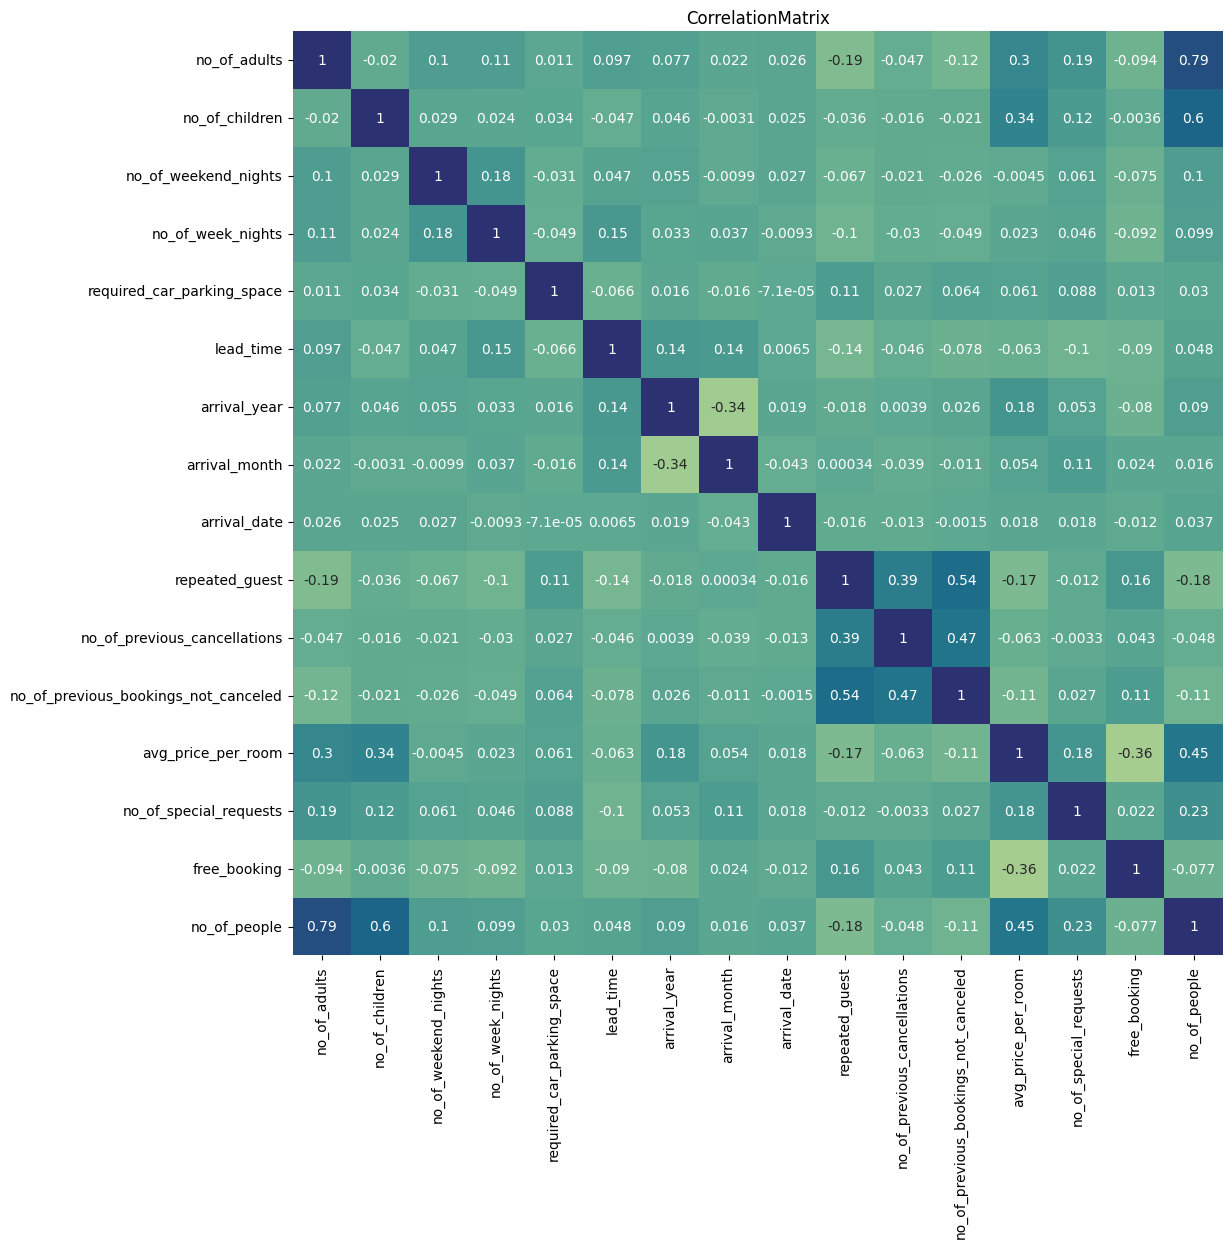

In [18]:
plt.figure(figsize=(12,12))
sns.heatmap(data=df.corr(numeric_only=True), cbar=False, annot=True, cmap='crest')
plt.title('CorrelationMatrix')
plt.show()

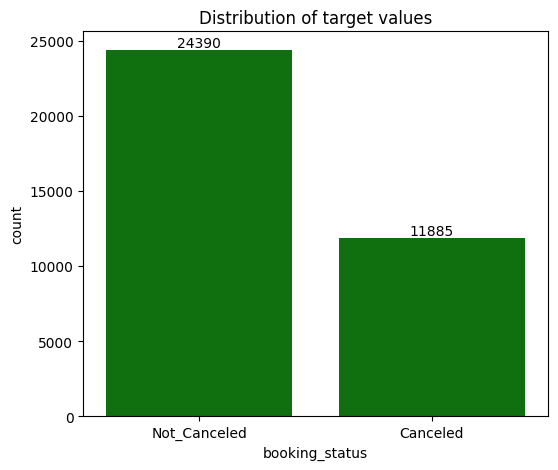

In [19]:
fig, ax = plt.subplots(figsize=(6,5))
sns.countplot(data=df, x='booking_status', color='green')
ax.bar_label(ax.containers[0])
plt.title('Distribution of target values')
plt.show()

In [20]:
df.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status',
       'arrival_fulldate', 'free_booking', 'no_of_people'],
      dtype='object')

In [21]:
obj_categories = df.select_dtypes(include='object').columns.to_list()
obj_categories.remove('Booking_ID')
obj_categories.remove('booking_status')
obj_categories.append('repeated_guest')
obj_categories

['type_of_meal_plan',
 'room_type_reserved',
 'market_segment_type',
 'repeated_guest']

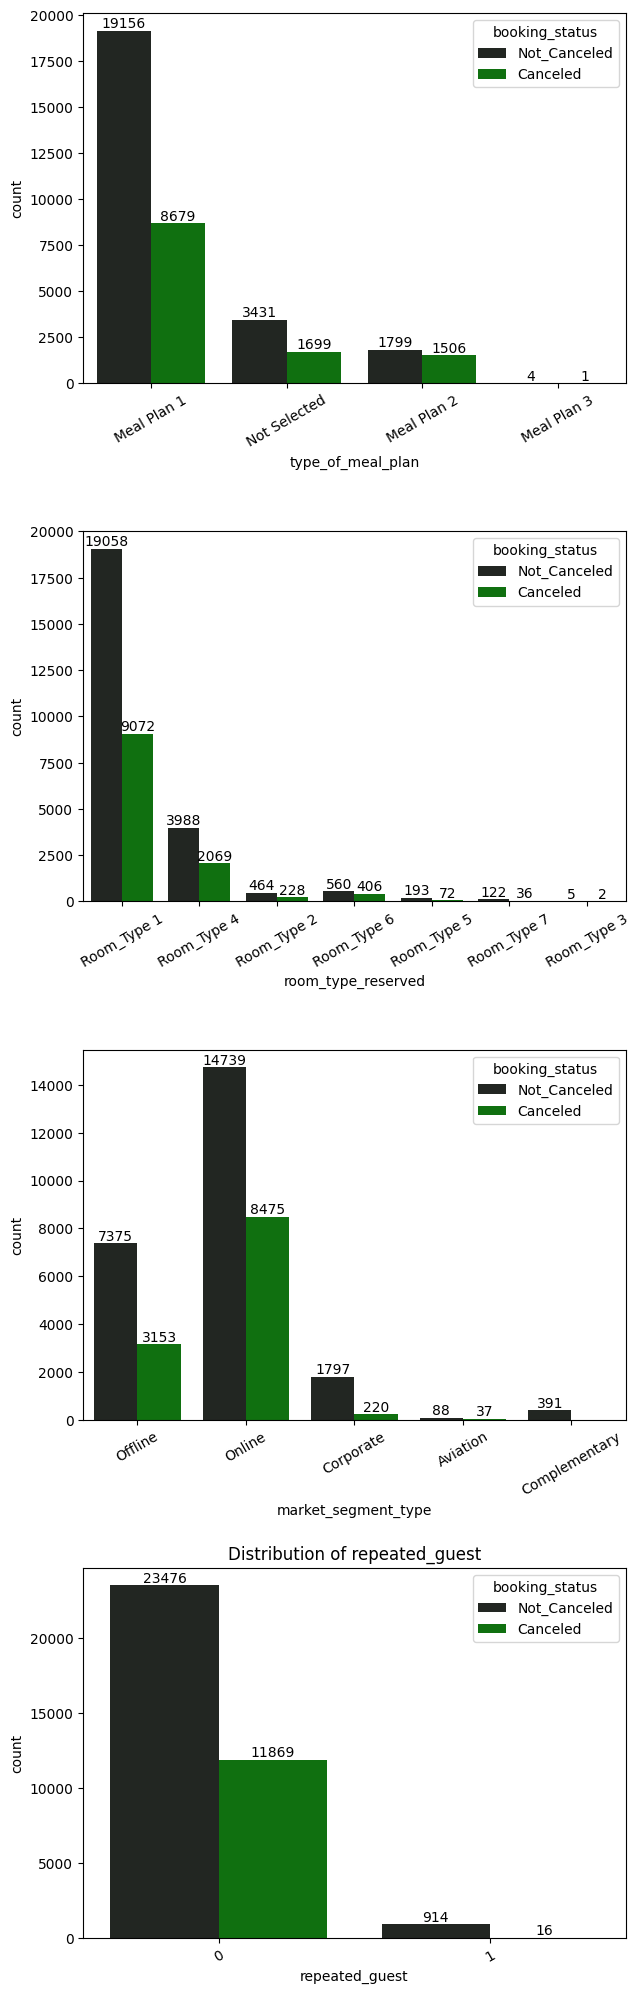

In [22]:
fig, ax = plt.subplots(4, 1, figsize=(7, 25))

for i, cat in enumerate(obj_categories):
    sns.countplot(data=df, x=cat, color='green', hue='booking_status', ax=ax[i])
    ax[i].bar_label(ax[i].containers[0])
    ax[i].bar_label(ax[i].containers[1])
    plt.title(f'Distribution of {cat}')
    ax[i].tick_params(axis='x', rotation=30)

fig.subplots_adjust(hspace=0.4, wspace=0.4)
plt.show()

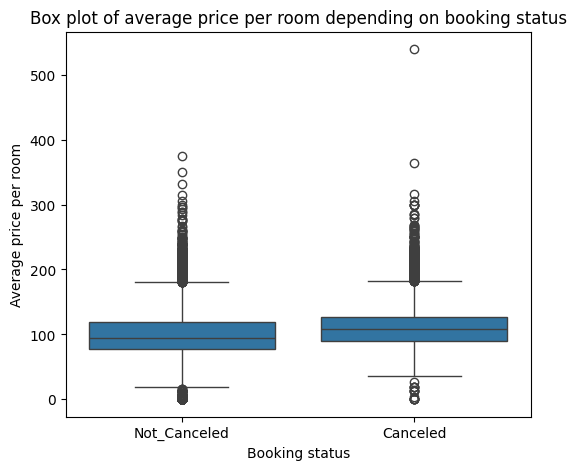

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x='booking_status', y='avg_price_per_room', ax=ax)
ax.set_title("Box plot of average price per room depending on booking status", fontsize=12)
ax.set_xlabel("Booking status")
ax.set_ylabel("Average price per room")
plt.show()


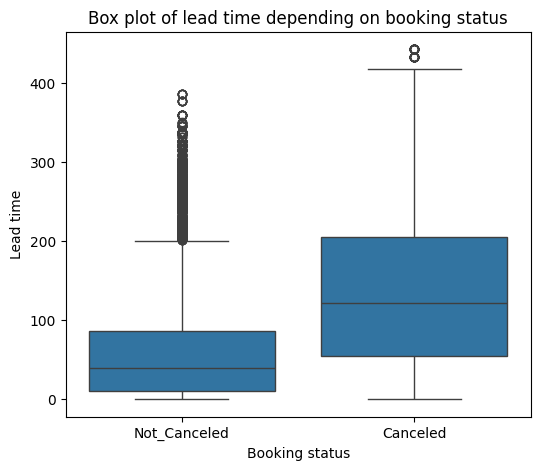

In [24]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x='booking_status', y='lead_time', ax=ax)
ax.set_title("Box plot of lead time depending on booking status", fontsize=12)
ax.set_xlabel("Booking status")
ax.set_ylabel("Lead time")
plt.show()

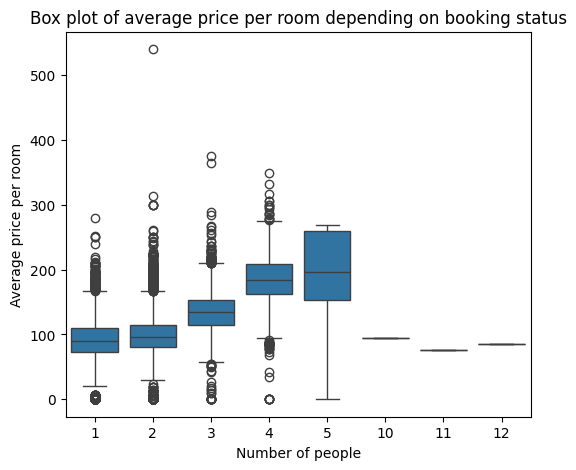

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x='no_of_people', y='avg_price_per_room', ax=ax)
ax.set_title("Box plot of average price per room depending on booking status", fontsize=12)
ax.set_xlabel("Number of people")
ax.set_ylabel("Average price per room")
plt.show()

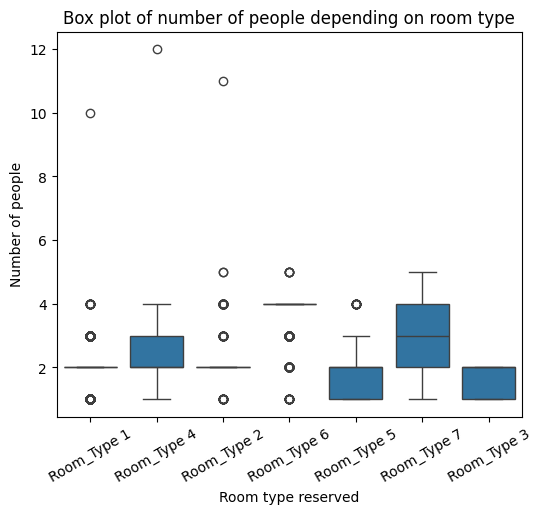

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x='room_type_reserved', y='no_of_people', ax=ax)
ax.set_title("Box plot of number of people depending on room type", fontsize=12)
ax.set_xlabel("Room type reserved")
ax.set_ylabel("Number of people")
ax.tick_params(axis='x', rotation=30)
plt.show()

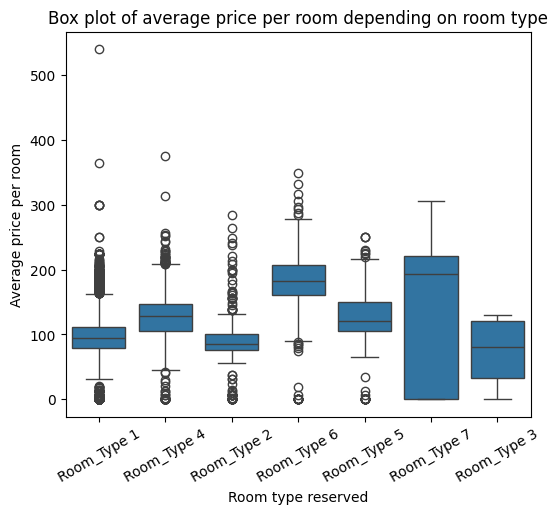

In [27]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df, x='room_type_reserved', y='avg_price_per_room', ax=ax)
ax.set_title("Box plot of average price per room depending on room type", fontsize=12)
ax.set_xlabel("Room type reserved")
ax.set_ylabel("Average price per room")
ax.tick_params(axis='x', rotation=30)
plt.show()

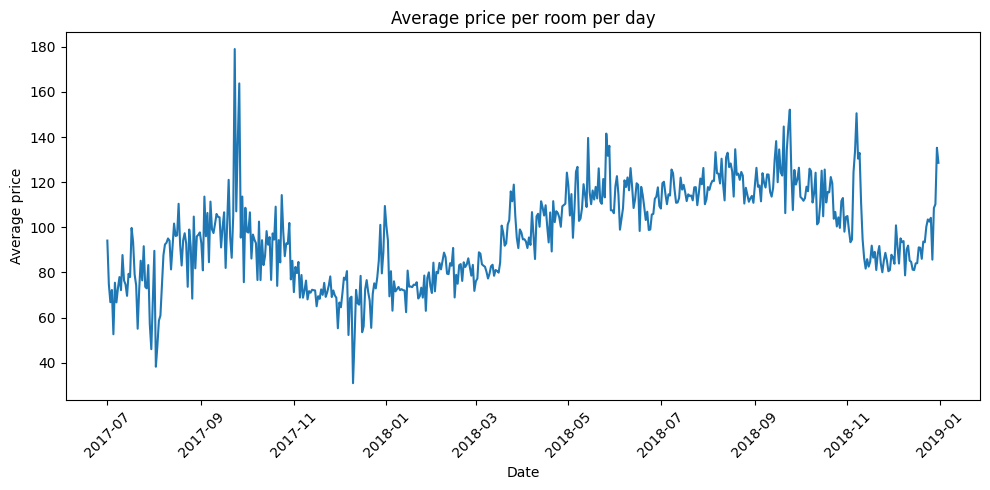

In [28]:
df = df.sort_values('arrival_fulldate')

df_daily = (
    df.groupby('arrival_fulldate', as_index=False)
      .agg(price_mean=('avg_price_per_room', 'mean'))
)

df_daily = df_daily.sort_values('arrival_fulldate')

# wykres
plt.figure(figsize=(10, 5))
plt.plot(df_daily['arrival_fulldate'], df_daily['price_mean'])

plt.xlabel('Date')
plt.ylabel('Average price')
plt.title('Average price per room per day')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

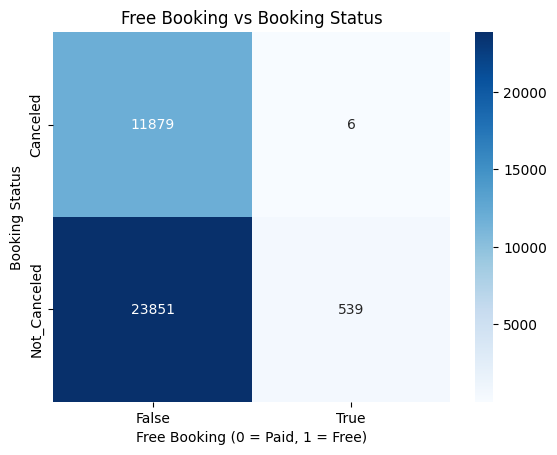

In [29]:
ct = pd.crosstab(df["booking_status"], df["free_booking"])
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Free Booking (0 = Paid, 1 = Free)")
plt.ylabel("Booking Status")
plt.title("Free Booking vs Booking Status")
plt.show()

In [30]:
df.to_csv('../data/eda_data.csv')